In [1]:
import ROOT
from scipy import interpolate as interpolate
from scipy.stats import norm
import numpy as np
from utils import NonUniformStat, append_to_dict
import json
from matplotlib import pyplot as plt

In [2]:
BIAS = {}

with open("bias_dictionary.json", "r", encoding="utf-8") as f:
    BIAS = json.load(f)

tot_event, Dmu, Dsigma, nB_value = 0,0,0,0
#distribution = [169, 162, 188, 133, 121, 130, 162, 137, 195, 171, 154]

# load configuration file and read the configurations
with open("config.txt", 'r') as file:
    for line in file:
        line = line.strip()
        line = line.replace(" ","")
        if not ("#" in line):
            print(line)
        if not line:
            continue
        if 'Ntot' in line:
            key, value = line.split('=')
            tot_event = int(value)
        if 'nB_val' in line:
            key, value = line.split('=')
            nB_val = int(value)
        if 'Dmu' in line:
            key, value = line.split('=')
            Dmu = float(value)
        if 'Dsigma' in line:
            key, value = line.split('=')
            Dsigma = float(value)
        if 'real_gravity' in line:
            key, value = line.split('=')
            real_gravity = float(value)
        if 'Ntoys' in line:
            key, value = line.split('=')
            Ntoys = int(value)



Dmu=+0.02
Dsigma=0.08
K=0.85
real_gravity=-10
Ntot=1100
nB_val=7
Ntoys=1000
pfraction=0.5


In [3]:
Dmu    = Dmu
Dsigma = Dsigma
L      = 4
print(Dmu)

0.02


In [6]:
def sample_steep_region(n=200, k=1, a=1, g = -10):
    """
    Campiona n punti nella regione ripida di tanh(kx).
    a definisce quanto 'larga' è la regione ripida (in unità di 1/k).
    """
    x_min = -a / k + g/10
    x_max = +a / k + g/10
    xs = np.linspace(x_min, x_max, n) * 10
    return xs, x_min, x_max

In [7]:
BIAS = {}
#biasList = np.linspace( (real_gravity/10 - L/2)*10, (real_gravity/10 + L/2)*10, 7)

# a = 1.84 correspond to +0.95 for up and -0.95 for down
biasList, xmin, xmax = sample_steep_region(7, L, a = 1.84, g = real_gravity)
print(f"Interval region: [{xmin:.2f},{xmax:.2f}]")
print(f"bias list is {biasList}")

for bias in biasList:
    BIAS.update({f"{(bias/10):.1f}g" : int(bias)})

print(BIAS)

weights = {} # define the dictionary containing the statistics
for key, value in BIAS.items():
    weights.update( {key: int(tot_event/len(BIAS.values())) })

Interval region: [-1.46,-0.54]
bias list is [-14.6        -13.06666667 -11.53333333 -10.          -8.46666667
  -6.93333333  -5.4       ]
{'-1.5g': -14, '-1.3g': -13, '-1.2g': -11, '-1.0g': -10, '-0.8g': -8, '-0.7g': -6, '-0.5g': -5}


# Spline approximated with LINEAR SLOPE

In [51]:
# def scurve_model(x, L, g):
#     result = 0
#     if((-L/2 + g) < x and x < ( L/2 + g)):
#         result = 2/L * (x - g)
#     elif((-L/2 +g) >= x):
#         result = -.99
#     elif(x >= ( L/2 + g )):
#         result = +.99
#     return result

def scurve_model(x, L, g):
    return np.tanh(L * (x - g))

print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at -1.5 : %.1f" % scurve_model(-1.5,2,-1))
print("linear scurve evaluated at -1 : %.1f" % scurve_model(-1,2,-1))
print("linear scurve evaluated at -.5 : %.1f" % scurve_model(-.5,2,-1))
print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at 0 : %.1f"  % scurve_model(0,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(1,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(10,2,-1))

linear scurve evaluated at -2 : -1.0
linear scurve evaluated at -1.5 : -0.8
linear scurve evaluated at -1 : 0.0
linear scurve evaluated at -.5 : 0.8
linear scurve evaluated at -2 : -1.0
linear scurve evaluated at 0 : 1.0
linear scurve evaluated at 1 : 1.0
linear scurve evaluated at 1 : 1.0


In [52]:
import csv

# ===  generate the True Asymemtry from Simulation
ASYMMETRY_TRUE = {}
for key, value in BIAS.items():
    ASYMMETRY_TRUE.update({key : float(scurve_model(value/10, L, real_gravity/10))})
    
print(ASYMMETRY_TRUE)

# Create simulation file
rows = []
for bias in np.linspace(-11, 9, 200):
    rows.append([bias, scurve_model(bias, L, real_gravity/10)])  # ogni riga = [bias, valore]
    print(bias, scurve_model(bias, L, 1) )

# save simulation file
with open("simulation.csv", "w", newline="") as f:
    writer = csv.writer(f)
    #writer.writerow(["bias", "scurve"])   # intestazioni opzionali
    writer.writerows(rows)

{'-1.5g': -0.9640275800758169, '-1.3g': -0.8336546070121553, '-1.2g': -0.3799489622552252, '-1.0g': 0.0, '-0.8g': 0.6640367702678489, '-0.7g': 0.9216685544064713, '-0.5g': 0.9640275800758169}
-11.0 -1.0
-10.899497487437186 -1.0
-10.798994974874372 -1.0
-10.698492462311558 -1.0
-10.597989949748744 -1.0
-10.49748743718593 -1.0
-10.396984924623116 -1.0
-10.296482412060302 -1.0
-10.195979899497488 -1.0
-10.095477386934673 -1.0
-9.99497487437186 -1.0
-9.894472361809045 -1.0
-9.793969849246231 -1.0
-9.693467336683417 -1.0
-9.592964824120603 -1.0
-9.492462311557789 -1.0
-9.391959798994975 -1.0
-9.291457286432161 -1.0
-9.190954773869347 -1.0
-9.090452261306533 -1.0
-8.989949748743719 -1.0
-8.889447236180905 -1.0
-8.78894472361809 -1.0
-8.688442211055277 -1.0
-8.587939698492463 -1.0
-8.487437185929648 -1.0
-8.386934673366834 -1.0
-8.28643216080402 -1.0
-8.185929648241206 -1.0
-8.085427135678392 -1.0
-7.984924623115578 -1.0
-7.884422110552764 -1.0
-7.78391959798995 -1.0
-7.683417085427136 -1.0
-

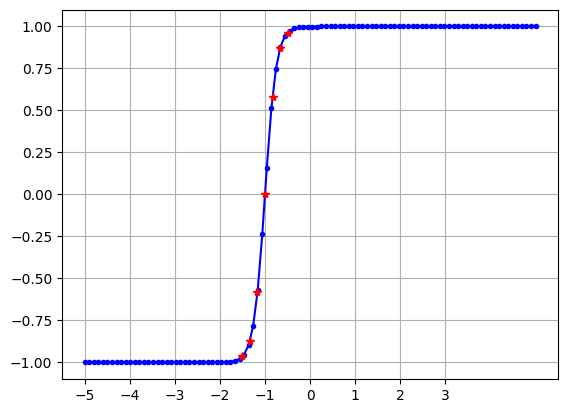

In [53]:
plt.figure(1)
xpoints = np.linspace(-5,5,100)
ypoints = [scurve_model(item, L, real_gravity/10) for item in xpoints]
plt.errorbar(xpoints, ypoints, marker = '.', color = 'blue')
plt.xticks([-5,-4,-3,-2,-1,0,1,2,3])
ypoints = [scurve_model(item/10, L, real_gravity/10) for item in biasList]
xpoints = np.array(biasList)/10
plt.errorbar(xpoints, ypoints, linestyle = "" ,marker = "*", color = "red")
plt.grid()
plt.savefig(f"scurve_L_{L}.png")

# Open The Workspace with the PDFs

In [8]:
f = ROOT.TFile("analysis_output/workspace.root")
w = f.Get("w")
w.Print("v")

w['c_pbarDn_1'].setVal(1.0); w['c_pbarDn_1'].setConstant(True)
w['c_pbarUp_1'].setVal(1.0); w['c_pbarUp_1'].setConstant(True)


RooWorkspace(w) w contents

variables
---------
(Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype)

p.d.f.s
-------
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooHistPdf::pdf_cosm[ pdfObs=(Z) ] = 1.8628
RooAddPdf::pdf_pbarDn[ c_pbarDn_1 * hpdf_pbarDn_1 + [%] * hpdf_pbarDn_2 ] = 0.0121951/1
RooAddPdf::pdf_pbarUp[ c_pbarUp_1 * hpdf_pbarUp_1 + [%] * hpdf_pbarUp_2 ] = 0.844512/1

datasets
--------
RooDataHist::rdhbin_pbarUp1(Z)
RooDataHist::rdhbin_pbarUp2(Z)
RooDataHist::rdhbin_pbarDn1(Z)
RooDataHist::rdhbin_pbarDn2(Z)

embedded datasets (in pdfs and functions)
-----------------------------------------
RooDataHist::rhcosm(Z)



In [9]:
Z = w['Z']
zframe = Z.frame(Title = "Z Distributions, Templates")
w['pdf_pbarUp'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kRed))
w['pdf_pbarDn'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kBlue))
w['pdf_cosm'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kGreen))

c = ROOT.TCanvas("pdfs_templates", "pdfs_templates", 600, 600)
ROOT.gPad.SetLeftMargin(0.15)
zframe.GetYaxis().SetTitleOffset(1.4)
zframe.Draw()
c.Draw()

# Create the RooDataSet

In [10]:
BiasCategory = ROOT.RooCategory("secondCategory", "a second category", BIAS)
BiasCategory.Print("v")

#dataset = ROOT.RooDataSet("data","data", ROOT.RooArgSet(Z,BiasCategory))

--- RooAbsArg ---
  Value State: clean
  Shape State: clean
  Attributes: 
  Address: 0x6414499566b0
  Clients: 
  Servers: 
  Proxies: 
--- RooAbsCategory ---
  Value = -30 "-3.0g)
  Possible states:
    -0.3g	-3
    -1.0g	-10
    -1.7g	-16
    -2.3g	-23
    -3.0g	-30
    0.3g	3
    1.0g	10


In [11]:
simModelBase = ROOT.RooSimultaneous("model_base_simultaneous", "model for bias", BiasCategory)

# 2. Crea un mapping da categoria (es. "-1.0g") a PDF personalizzato

pdf_per_categoria = {} # senno muoiono

for category, weight in weights.items():
    print(f"Setting up PDF for category: {category}")
    
    # Calcolo degli eventi Up/Down
    Nup   = 0.5 * weight * (1 - ASYMMETRY_TRUE[category])
    Ndown = 0.5 * weight * (1 + ASYMMETRY_TRUE[category])
    
    # Costanti per RooAddPdf
    nup_const = ROOT.RooFit.RooConst(Nup)
    ndwn_const = ROOT.RooFit.RooConst(Ndown)
    
    # PDF composita per questa categoria
    model_i = ROOT.RooAddPdf(f"pdf_{category}", f"pdf_{category}",
                             ROOT.RooArgList(w['pdf_pbarUp'], w['pdf_pbarDn']),
                             ROOT.RooArgList(nup_const, ndwn_const))
    pdf_per_categoria[category] = model_i
    
    # Aggiungila alla simultanea
    simModelBase.addPdf(model_i, category)

Setting up PDF for category: -3.0g
Setting up PDF for category: -2.3g
Setting up PDF for category: -1.7g
Setting up PDF for category: -1.0g
Setting up PDF for category: -0.3g
Setting up PDF for category: 0.3g
Setting up PDF for category: 1.0g


In [12]:
# Generazione separata per ciascuna categoria
dataset = simModelBase.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
dataset.Print("v")

DataStore hmaster (hmaster)
  Contains 14 entries
  Observables: 
    1)               Z = -450  L(-875.35 - -219.35) B(2)  "Z"
    2)  secondCategory = 1.0g(idx = 10)
  "a second category"


In [13]:
ttable = dataset.table(BiasCategory)
ttable.Print("v")


  Table secondCategory : hmaster
  +-------+-----+
  | -3.0g | 172 |
  | -2.3g | 170 |
  | -1.7g | 157 |
  | -1.0g | 176 |
  | -0.3g | 133 |
  |  0.3g | 163 |
  |  1.0g | 160 |
  +-------+-----+



In [14]:
c1 = ROOT.TCanvas("data_plot", "data_plot", 800, 800)

zframe1 = Z.frame( ROOT.RooFit.Bins(18), Title = "Plot of Z data")
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -30'), ROOT.RooFit.MarkerColor(ROOT.kBlue),  ROOT.RooFit.Name("cat_-30"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -20'), ROOT.RooFit.MarkerColor(ROOT.kRed),   ROOT.RooFit.Name("cat_-20"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == 30'), ROOT.RooFit.MarkerColor(ROOT.kGreen),  ROOT.RooFit.Name("cat_+30"))
#dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == +20'), ROOT.RooFit.MarkerColor(6),   ROOT.RooFit.Name("cat_-20"))
#w['model_base'].plotOn(zframe1)

#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kBlue))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-2.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kRed))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "+3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kGreen))

zframe1.Draw()

# Crea la legenda
legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)  # x1,y1,x2,y2 in NDC (posizione)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(zframe1.findObject("cat_-30"), "-3.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_-20"), "-2.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_+30"), "+3.0g", "lep")
legend.Draw()

c1.Draw()

[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 172 events out of 1131 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1131 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1131 total events


# Construction of the model for the Simulation

In [15]:
w.Import(BiasCategory) # <== Import the category inside the workspace

w.factory("S[100,50, 10000]")
w.factory("E[0.0, -1.5, 1.5]")
w.factory(f"D[{Dmu}, -0.8, 0.8]")

w.factory("SUM::model_base( Nup[30,10000] * pdf_pbarUp, Ndwn[30,1000] * pdf_pbarDn, nB[1, 200] * pdf_cosm)") # <<< Add pdf_cosm in the future
# A = (Ndwn - Nup)/(Ndwn + Nup)
w.factory(f"EDIT::model_MAGB(model_base, Nup=expr('0.5*S*(1-E)', S, E), Ndwn = expr('0.5*S*(1+E)', S, E))")

w.factory(f"Gaussian::Dconstr(D,{Dmu},{Dsigma})") # constrain on D, efficiency

w.factory("SIMCLONE::model_fit( model_MAGB, $SplitParam({S,E}, secondCategory ))") # Clone the Models

w.Print()

[#1] INFO:ObjectHandling -- RooWorkspace::import(w) importing RooCategory::secondCategory

RooWorkspace(w) w contents

variables
---------
(D,E,E_-0.3g,E_-1.0g,E_-1.7g,E_-2.3g,E_-3.0g,E_0.3g,E_1.0g,Ndwn,Nup,S,S_-0.3g,S_-1.0g,S_-1.7g,S_-2.3g,S_-3.0g,S_0.3g,S_1.0g,Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype,nB,secondCategory)

p.d.f.s
-------
RooGaussian::Dconstr[ x=D mean=0.02 sigma=0.08 ] = 1
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooAddPdf::model_MAGB[ model_MAGB_2 * pdf_pbarUp + model_MAGB_3 * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.3g[ model_MAGB_2_-0.3g * pdf_pbarUp + model_MAGB_3_-0.3g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-1.0g[ model_MAGB_2_-1.0g * pdf_pbarUp + model_MAGB_3_-1.0g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-1

In [16]:
g = ROOT.TGraph("simulation.csv","%lg,%lg")
# create RooRealVar
w.factory('c[0,-30,30]')
#create RooRealVar
w.factory('scale[0.1]')
#w['scale'].setConstant(True)
w["nB"].setVal(nB_val)

# === Definisci la curva S come TF1 + RooTFnBinding ===
def Scurve_fn(x, p):
    # 10 is an offset of the simulation
    offset = -10
    bias = x[0]
    c = p[0]
    scale = p[1]
    D = p[2]
    return (g.Eval((x[0] - c + offset) * scale) - D)/(1 - g.Eval((x[0] - c + offset) * scale)*D)

# === Print values of the Scurve for a collection of biases ===
print("-"*8)
for key,value in BIAS.items():
    val = Scurve_fn([value], [w["c"].getVal(), w['scale'].getVal(), w['D'].getVal()])
    print(f"{key}| {value} | {w['c'].getVal()} | {val}")
print("-"*8)

# === create the RooFit model from the Scurve ===
Scurve_TF1 = ROOT.TF1("Scurve",Scurve_fn, -50, 50, 3) # not possible to put in workspace

cust = ROOT.RooCustomizer(w.pdf('model_fit'), "scurve");

vcat={}
nasy={}
for bkt, bias_val in BIAS.items():
    v = ROOT.RooRealVar(f"vat_{bkt}", "", bias_val)
    # Creo una funzione parametrica RooTFnBinding che connette il TF1 alla variabile 'v'
    # Il TF1 ha 3 parametri: c, scale, D — sono usati qui come [c, scale, D]
    asy = ROOT.RooTFnBinding(f"nasy_{bkt}", "", Scurve_TF1, v, [w['c'], w['scale'], w['D']])
    # Salvo queste entità nei dizionari
    vcat[bkt] = v
    nasy[bkt] = asy

    # Ottengo la variabile originale 'E_{bkt}' nel modello
    A = w.var(f'E_{bkt}')

    # Sostituisco E_{bkt} con la funzione curva S corrispondente
    cust.replaceArg(A, asy)

scurve_all = cust.build(True)

scurvemap = {}
for bkt, bias_val in BIAS.items():
    scurvemap.update({bkt : scurve_all.getPdf(bkt) })
    S = w.var(f'S_{bkt}')

    val = ttable.get(bkt)
    err = np.sqrt(val)
    
    #S.setMin(val-10*err)
    #S.setMax(val+10*err)
    S.setVal(val)
    print(f"setting  {val}  [{val - 10*err}  {val + 10*err}]")
    #S.setError(err)

scurve_fit = ROOT.RooSimultaneous("scurve_fit","scurve_fit", scurvemap, BiasCategory)

--------
-3.0g| -30 | 0.0 | -0.9999999999224686
-2.3g| -23 | 0.0 | -0.9999999789519807
-1.7g| -16 | 0.0 | -0.9999942894158793
-1.0g| -10 | 0.0 | -0.9993047783870286
-0.3g| -3 | 0.0 | -0.8297670646339846
0.3g| 3 | 0.0 | 0.8168851945841257
1.0g| 10 | 0.0 | 0.9992468891889015
--------
setting  172.0  [40.85122951395999  303.14877048604]
setting  170.0  [39.615951895947006  300.384048104053]
setting  157.0  [31.700359138583323  282.29964086141666]
setting  176.0  [43.33500838578402  308.664991614216]
setting  133.0  [17.67437405329204  248.32562594670796]
setting  163.0  [35.32854665196297  290.67145334803706]
setting  160.0  [33.508893593264816  286.4911064067352]
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.3g will be replaced by nasy_-0.3g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.0g will be replaced by nasy_-1.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.7g will be replaced by nasy_-1.7g


In [17]:
w['D'].setConstant(True)

w['c'].setError(20)
result = scurve_fit.fitTo(dataset,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.Minos(w['c']))

c     = w.var('c')
scale = w.var('scale')
D = w.var('D')

# === 8. Risultati
print("\n=== RISULTATI DEL FIT ===")
print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
print(f"fit status: {result.status()}")


=== RISULTATI DEL FIT ===
c     = -1.0255 ± 0.0195; [-0.019162738542919826,+0.019740708706004577]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using CPU computation library compiled with -mavx2
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 4500 convergence for edm < 1 strategy 2
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 4311.46783331118422
Edm   = 0.000106185657454751435
Nfcn  = 504
S_-0.3g	  = 132.284	 +/-  11.5313	(limited)
S_-1.0g	  = 175.073	 +/-  13.2698	(limited)
S_-1.7g	  = 156.239

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       4820.993453 Edm =       283.2540973 NCalls =     39
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.233181
Info in <Minuit2>: MnSeedGenerator run Hesse - Initial seeding state: 
  Minimum value : 4820.993453
  Edm           : 19421.87608
  Internal parameters:	[     -1.387875502     -1.345255787     -1.363022033      -1.35071362     -1.348879675     -1.357254402     -1.360118772                0     -1.221747644]	
  Internal gradient  :	[      207.2129551      404.4599915       29.8450837      41.52682676      24.72900389      27.16202098      27.92399481      2211.671847     -334.8465635]	
  Internal covariance matrix:
[[    0.041080593    0.025468396   0.0033313904   0.0037248667   0.0029581148   0.0038158915   0.0035476984   -0.019224029    -0.23683753]
 [    0.025468396    0.016230924   0.0020832875   0.00232

In [18]:
scurve_fit.getParameters(dataset).Print('v')

  1) 0x64144a034d70 RooRealVar::          D = 0.02 C  L(-0.8 - 0.8)  "D"
  2) 0x64144a547eb0 RooRealVar::    S_-0.3g = 132.284 +/- 11.5312  L(50 - 10000)  "S (-0.3g)"
  3) 0x64144a50d230 RooRealVar::    S_-1.0g = 175.073 +/- 13.2698  L(50 - 10000)  "S (-1.0g)"
  4) 0x64144a516df0 RooRealVar::    S_-1.7g = 156.239 +/- 12.5279  L(50 - 10000)  "S (-1.7g)"
  5) 0x64144a478030 RooRealVar::    S_-2.3g = 168.474 +/- 13.0321  L(50 - 10000)  "S (-2.3g)"
  6) 0x64144a481bf0 RooRealVar::    S_-3.0g = 171.335 +/- 13.1141  L(50 - 10000)  "S (-3.0g)"
  7) 0x64144a48b7a0 RooRealVar::     S_0.3g = 162.207 +/- 12.7622  L(50 - 10000)  "S (0.3g)"
  8) 0x64144a495350 RooRealVar::     S_1.0g = 159.226 +/- 12.6452  L(50 - 10000)  "S (1.0g)"
  9) 0x64144a440070 RooRealVar::          c = -10.2548 +/- (-0.191627,0.197407)  L(-30 - 30)  "c"
 10) 0x641446685dd0 RooRealVar:: c_pbarDn_1 = 1 C  L(0.71251 - 1)  "c_pbarDn_1"
 11) 0x6414427b6930 RooRealVar:: c_pbarUp_1 = 1 C  L(-0.0202152 - 1)  "c_pbarUp_1"
 12) 0x641

# SIMULATION, nominal case (2023 analysis), D set as constant

In [19]:
Ngravity = []
dNgravity = []

D.setConstant(True)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)

    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())
        
    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9917 ± 0.0206; [-0.020522640798221508,+0.02054048844375424]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9806 ± 0.0200; [-0.02004380184314846,+0.019995894043711774]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set 


=== RISULTATI DEL FIT ===
c     = 0.0120 ± 0.0520; [-0.052372872281542415,+0.05163663523803933]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0301 ± 0.0532; [-0.05298192454285673,+0.05340290550331836]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set val


=== RISULTATI DEL FIT ===
c     = -0.0012 ± 0.0508; [-0.05154647216529339,+0.05151980282065767]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.1113 ± 0.0514; [-0.05134083488496987,+0.051446361843866556]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va


=== RISULTATI DEL FIT ===
c     = -0.0529 ± 0.0517; [-0.052703772213170685,+0.05039033720003268]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0119 ± 0.0507; [-0.05147418396068616,+0.04981971961036931]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set v


=== RISULTATI DEL FIT ===
c     = 0.0291 ± 0.0521; [-0.05191139607154615,+0.052142941476898345]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.1304 ± 0.0503; [-0.050357917849416504,+0.05040883842198177]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va

...


=== RISULTATI DEL FIT ===
c     = 0.0142 ± 0.0507; [-0.05243402863856799,+0.05201605989161809]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0752 ± 0.0540; [-0.0520348501979572,+0.05151763323483225]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set valu

tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0697 ± 0.0515; [-0.050950423880782164,+0.05189183780970685]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 


=== RISULTATI DEL FIT ===
c     = -0.0429 ± 0.0535; [-0.051506118890238095,+0.05198466316051625]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0099 ± 0.0511; [-0.05210304869955752,+0.05205445384353824]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va


=== RISULTATI DEL FIT ===
c     = 0.0933 ± 0.0519; [-0.05068252828493445,+0.050938428421591776]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0691 ± 0.0518; [-0.05229667443741738,+0.051427973746353384]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set v


=== RISULTATI DEL FIT ===
c     = 0.0403 ± 0.0508; [-0.05100876396574298,+0.05110176284860468]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0256 ± 0.0526; [-0.05266404874761447,+0.05110595077090287]
scale = 0.1000 ± 0.0000
D     = 0.0000 ± 0.0000
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set valu

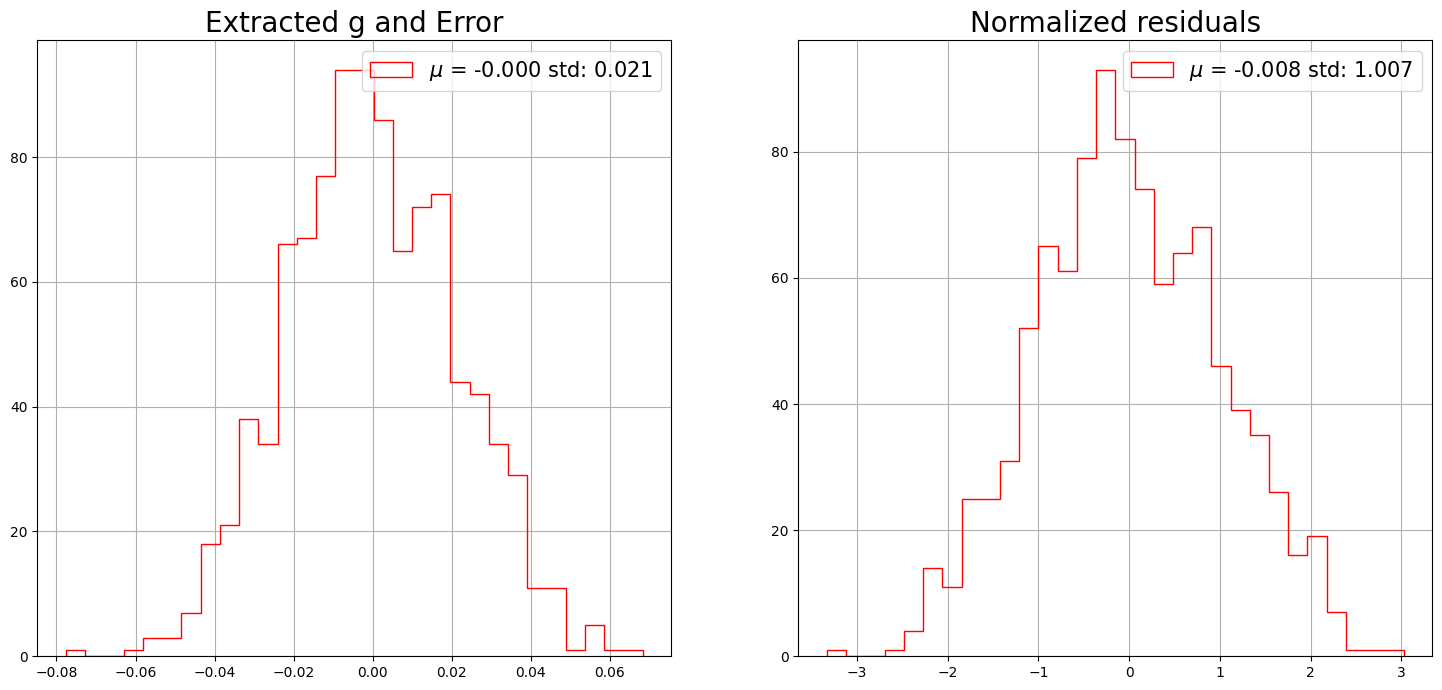

In [20]:
from matplotlib import pyplot as plt

#print(res_norm)
plt.figure(9, figsize = (18,8))
plt.subplot(1,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.subplot(1,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.savefig(f"residuals_L_{L}.png", bbox_inches = 'tight')

# Fit with D

In [21]:
Ngravity = []
dNgravity = []
ND = []
dND = []

D.setConstant(False)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)
    D.setVal(Dmu + np.random.normal(loc = 0, scale = Dsigma))  # D detector asymmetry, add a "manual smearing, because the simulation does not account for a generation of D"
    
    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())

    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 #ROOT.RooFit.Verbose(False),   # disattiva log verboso
                 #ROOT.RooFit.Warnings(False),  # opzionale: disattiva warning
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())
        ND.append(D.getVal() - Dmu)
        dND.append(D.getError())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)
Dres_norm = (np.array((ND)))/np.array(dND)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9709 ± 0.0285; [-0.028667466245504813,+0.02950411901139274]
scale = 0.1000 ± 0.0000
D     = 0.0210 ± 0.0794
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9542 ± 0.0293; [-0.029692739562846467,+0.032303501621005294]
scale = 0.1000 ± 0.0000
D     = 0.0198 ± 0.0797
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set


=== RISULTATI DEL FIT ===
c     = 0.0184 ± 0.0896; [-0.09875400143658412,+0.09839603877637332]
scale = 0.1000 ± 0.0000
D     = 0.0117 ± 0.0453
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0554 ± 0.0870; [-0.09579230047754361,+0.09565425316578147]
scale = 0.1000 ± 0.0000
D     = -0.0455 ± 0.0452
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va


=== RISULTATI DEL FIT ===
c     = 0.1568 ± 0.0892; [-0.0896836838783584,+0.09043366410428273]
scale = 0.1000 ± 0.0000
D     = -0.0244 ± 0.0458
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.1078 ± 0.0911; [-0.09144832584766976,+0.09130925898158895]
scale = 0.1000 ± 0.0000
D     = -0.0169 ± 0.0465
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va


=== RISULTATI DEL FIT ===
c     = 0.0778 ± 0.0890; [-0.08887198389964625,+0.08944346340244791]
scale = 0.1000 ± 0.0000
D     = -0.0476 ± 0.0461
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0485 ± 0.0886; [-0.08821662027177747,+0.08934411587458671]
scale = 0.1000 ± 0.0000
D     = -0.0480 ± 0.0456
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va


=== RISULTATI DEL FIT ===
c     = -0.0545 ± 0.0959; [-0.08863917341134599,+0.08661565153056144]
scale = 0.1000 ± 0.0000
D     = -0.0522 ± 0.0479
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0627 ± 0.0919; [-0.08971360316380393,+0.09021358201253649]
scale = 0.1000 ± 0.0000
D     = 0.0291 ± 0.0467
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set v

...


=== RISULTATI DEL FIT ===
c     = -0.0120 ± 0.0861; [-0.08775439122692312,+0.08524704242057707]
scale = 0.1000 ± 0.0000
D     = -0.0530 ± 0.0448
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0479 ± 0.0930; [-0.09339771620931783,+0.09192953313071438]
scale = 0.1000 ± 0.0000
D     = -0.0336 ± 0.0473
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set 


=== RISULTATI DEL FIT ===
c     = -0.1348 ± 0.0885; [-0.09171445841014349,+0.09160603685361371]
scale = 0.1000 ± 0.0000
D     = -0.0428 ± 0.0461
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.0850 ± 0.0911; [-0.09038645780650391,+0.09213673419860392]
scale = 0.1000 ± 0.0000
D     = -0.1122 ± 0.0458
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set v


=== RISULTATI DEL FIT ===
c     = -0.0511 ± 0.0875; [-0.0865495073073923,+0.08840737866099227]
scale = 0.1000 ± 0.0000
D     = -0.0591 ± 0.0457
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = 0.1237 ± 0.0979; [-0.08808533224919272,+0.086662104420679]
scale = 0.1000 ± 0.0000
D     = -0.0360 ± 0.0490
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set valu


=== RISULTATI DEL FIT ===
c     = 0.0476 ± 0.0840; [-0.0945942781032934,+0.09920397620769501]
scale = 0.1000 ± 0.0000
D     = -0.0962 ± 0.0442
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.0712 ± 0.0876; [-0.08875228714950752,+0.08611895303524743]
scale = 0.1000 ± 0.0000
D     = 0.0024 ± 0.0454
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set val


=== RISULTATI DEL FIT ===
c     = 0.0436 ± 0.0868; [-0.09379087498382557,+0.09498414452881229]
scale = 0.1000 ± 0.0000
D     = 0.0143 ± 0.0452
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0

=== RISULTATI DEL FIT ===
c     = -0.1341 ± 0.0920; [-0.09175406828498531,+0.09125695381981877]
scale = 0.1000 ± 0.0000
D     = -0.0415 ± 0.0468
fit status: 0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set value: 180.0
tot_events: 180 set va

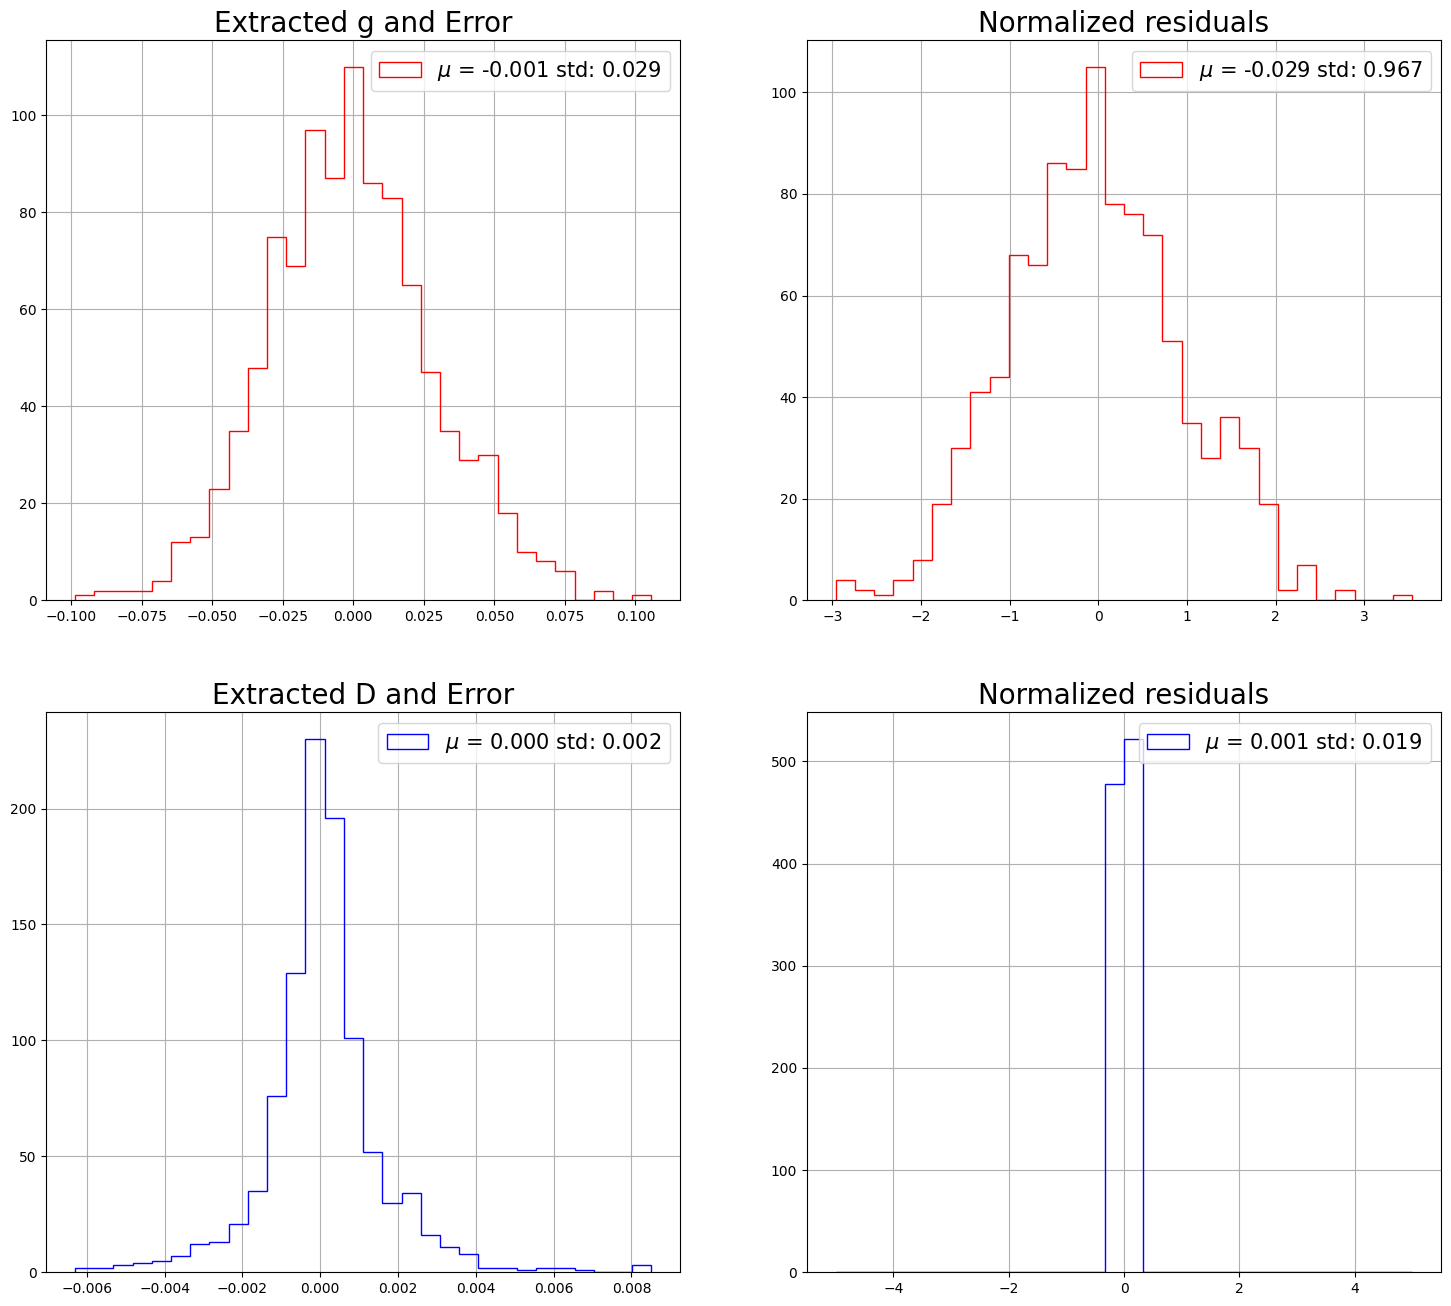

In [22]:
#print(res_norm)
plt.figure(10, figsize = (18,16))
plt.subplot(2,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

#plt.figure(11, figsize = (18,8))
plt.subplot(2,2,3)
plt.title("Extracted D and Error", fontsize = 20)
plt.grid()
plt.hist(ND, bins = 30, histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(ND):.3f} std: {np.std(ND):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,4)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(Dres_norm, bins = 30, range = (-5, 5), histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(Dres_norm):.3f} std: {np.std(Dres_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

plt.savefig(f"residuals_D_L_{L}.png", bbox_inches = 'tight')